In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

sns.set_theme(style="white", font="sans-serif")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.sans-serif"] = ["Arial"]

In [2]:
spa_plan_plot_data = {
    'Pangu-NLP-N2-128K': [12.6, 12.333333333333334, 12.533333333333331, 12.6, 13.0],
    'Pangu-NLP-N2-128K (Knowledge Agent)': [14.133333333333333, 14.066666666666668, 13.933333333333332, 14.066666666666668, 14.0],
    'Pangu-NLP-N2-Reasoner-128K': [13.533333333333331, 13.6, 13.333333333333334, 13.4, 13.466666666666669],
    'Pangu-NLP-N2-Reasoner-128K (Knowledge Agent)': [18.466666666666665, 18.6, 18.466666666666665, 18.6, 18.466666666666665],
    'Phyto-ChatBot': [14.6, 14.733333333333334, 14.6, 15.066666666666665, 14.733333333333334],
    'Phyto-ChatBot (Knowledge Agent)': [19.6, 19.466666666666665, 18.866666666666664, 18.6, 19.6],
    'Phyto-Reasoner': [17.466666666666665, 17.400000000000002, 17.266666666666666, 17.400000000000002, 17.466666666666665],
    'Phyto-Reasoner (Knowledge Agent)': [19.466666666666665, 19.6, 19.73333333333333, 19.266666666666666, 19.666666666666668],
    'GPT-5': [20.466666666666665, 20.6, 19.866666666666664, 20.266666666666666, 20.133333333333333],
    'o3': [20.53333333333333, 20.666666666666668, 20.46666666666667, 20.53333333333333, 20.73333333333333],
    'Gemini-2.5-Pro': [19.933333333333334, 20.066666666666663, 19.4, 19.73333333333333, 19.8],
    'Claude-Opus-4.1': [19.933333333333334, 20.266666666666666, 19.8, 20.33333333333333, 20.133333333333336],
    'Grok-3-Beta': [17.333333333333332, 17.333333333333332, 16.933333333333334, 17.0, 17.333333333333332],
    'DeepSeek-V3': [19.0, 19.4, 19.133333333333333, 19.4, 19.53333333333333],
    'DeepSeek-R1': [19.33333333333333, 19.266666666666666, 18.866666666666664, 19.133333333333333, 19.53333333333333],
}
spa_tool_plot_data = {
    'Pangu-NLP-N2-128K': [9.466666666666669, 9.0, 9.133333333333333, 9.266666666666667, 9.4],
    'Pangu-NLP-N2-128K (Knowledge Agent)': [12.2, 12.2, 12.133333333333336, 11.866666666666667, 12.2],
    'Pangu-NLP-N2-Reasoner-128K': [11.666666666666666, 11.533333333333331, 11.8, 11.733333333333334, 12.199999999999998],
    'Pangu-NLP-N2-Reasoner-128K (Knowledge Agent)': [17.266666666666666, 16.8, 17.133333333333333, 16.599999999999998, 17.133333333333333],
    'Phyto-ChatBot': [14.933333333333332, 14.933333333333332, 14.8, 15.0, 14.866666666666664],
    'Phyto-ChatBot (Knowledge Agent)': [18.46666666666667, 18.2, 17.8, 17.599999999999998, 18.266666666666666],
    'Phyto-Reasoner': [16.133333333333336, 16.333333333333332, 16.333333333333332, 16.266666666666666, 16.2],
    'Phyto-Reasoner (Knowledge Agent)': [18.933333333333334, 20.466666666666665, 20.466666666666665, 20.066666666666663, 20.33333333333333],
    'GPT-5': [19.266666666666666, 20.0, 18.933333333333334, 19.53333333333333, 19.866666666666667],
    'o3': [19.6, 19.666666666666668, 19.46666666666667, 19.46666666666667, 19.53333333333333],
    'Gemini-2.5-Pro': [18.4, 18.933333333333334, 18.2, 18.2, 18.46666666666667],
    'Claude-Opus-4.1': [20.6, 20.466666666666665, 20.4, 20.73333333333333, 20.4],
    'Grok-3-Beta': [16.066666666666666, 16.733333333333334, 16.533333333333335, 16.333333333333332, 16.133333333333333],
    'DeepSeek-V3': [18.666666666666668, 18.666666666666668, 18.73333333333333, 18.33333333333333, 18.53333333333333],
    'DeepSeek-R1': [18.8, 19.2, 18.8, 19.133333333333333, 18.933333333333334],
}
spa_param_plot_data = {
    'Pangu-NLP-N2-128K': [9.666666666666666, 10.066666666666668, 9.666666666666666, 9.6, 10.066666666666668],
    'Pangu-NLP-N2-128K (Knowledge Agent)': [15.266666666666666, 15.466666666666669, 15.133333333333333, 15.2, 15.466666666666669],
    'Pangu-NLP-N2-Reasoner-128K': [10.666666666666666, 10.866666666666667, 10.666666666666666, 11.066666666666668, 10.533333333333331],
    'Pangu-NLP-N2-Reasoner-128K (Knowledge Agent)': [17.599999999999998, 17.933333333333334, 17.666666666666668, 17.733333333333334, 17.666666666666668],
    'Phyto-ChatBot': [13.0, 13.066666666666668, 12.866666666666667, 12.8, 12.666666666666666],
    'Phyto-ChatBot (Knowledge Agent)': [18.6, 19.0, 18.6, 19.33333333333333, 18.6],
    'Phyto-Reasoner': [15.0, 14.933333333333332, 14.933333333333332, 15.133333333333333, 15.0],
    'Phyto-Reasoner (Knowledge Agent)': [21.46666666666667, 21.53333333333333, 21.33333333333333, 21.46666666666667, 21.46666666666667],
    'GPT-5': [17.46666666666667, 17.599999999999998, 18.466666666666665, 17.733333333333334, 17.8],
    'o3': [17.400000000000002, 17.066666666666666, 17.266666666666666, 17.133333333333333, 17.266666666666666],
    'Gemini-2.5-Pro': [16.733333333333334, 17.133333333333333, 16.866666666666667, 17.066666666666666, 16.733333333333334],
    'Claude-Opus-4.1': [18.46666666666667, 18.53333333333333, 18.46666666666667, 18.8, 18.46666666666667],
    'Grok-3-Beta': [14.133333333333333, 14.266666666666666, 13.866666666666667, 14.4, 14.333333333333334],
    'DeepSeek-V3': [15.2, 15.333333333333334, 15.066666666666668, 15.2, 15.266666666666666],
    'DeepSeek-R1': [14.4, 14.066666666666668, 14.4, 14.4, 14.333333333333334],
}
spa_rate_plot_data = {
    'Pangu-NLP-N2-128K': [6.0, 6.25, 6.083333333333333, 6.083333333333333, 6.0],
    'Pangu-NLP-N2-128K (Knowledge Agent)': [7.416666666666667, 7.416666666666667, 7.333333333333333, 7.5, 7.25],
    'Pangu-NLP-N2-Reasoner-128K': [7.083333333333333, 7.0, 6.75, 7.0, 6.583333333333333],
    'Pangu-NLP-N2-Reasoner-128K (Knowledge Agent)': [7.333333333333333, 7.833333333333333, 7.75, 7.916666666666667, 8.333333333333334],
    'Phyto-ChatBot': [7.75, 8.166666666666666, 7.5, 7.833333333333333, 7.916666666666667],
    'Phyto-ChatBot (Knowledge Agent)': [8.5, 8.75, 8.25, 8.416666666666666, 8.416666666666666],
    'Phyto-Reasoner': [8.666666666666666, 9.166666666666666, 8.555555555555555, 8.5, 8.5],
    'Phyto-Reasoner (Knowledge Agent)': [10.416666666666666, 10.833333333333334, 9.583333333333334, 10.833333333333334, 11.25],
    'GPT-5': [10.833333333333334, 11.25, 9.583333333333334, 10.416666666666666, 10.416666666666666],
    'o3': [7.083333333333333, 7.5, 6.916666666666667, 7.083333333333333, 7.083333333333333],
    'Gemini-2.5-Pro': [7.083333333333333, 7.5, 7.0, 7.083333333333333, 7.5],
    'Claude-Opus-4.1': [8.333333333333334, 7.916666666666667, 7.833333333333333, 7.5, 8.75],
    'Grok-3-Beta': [10.0, 10.416666666666666, 9.333333333333334, 9.166666666666666, 8.75],
    'DeepSeek-V3': [7.083333333333333, 7.083333333333333, 6.5, 7.083333333333333, 7.083333333333333],
    'DeepSeek-R1': [9.166666666666666, 8.75, 8.416666666666666, 8.75, 8.75],
}
columns_all = [
    'Arabidopsis thaliana',
    'Glycine max',
    'Oryza sativa',
    'Triticum aestivum',
    'Zea mays'
]
plot_plan_df = pd.DataFrame(spa_plan_plot_data).T
plot_plan_df.columns = columns_all
plot_tool_df = pd.DataFrame(spa_tool_plot_data).T
plot_tool_df.columns = columns_all
plot_param_df = pd.DataFrame(spa_param_plot_data).T
plot_param_df.columns = columns_all
plot_rate_df = pd.DataFrame(spa_rate_plot_data).T
plot_rate_df.columns = columns_all

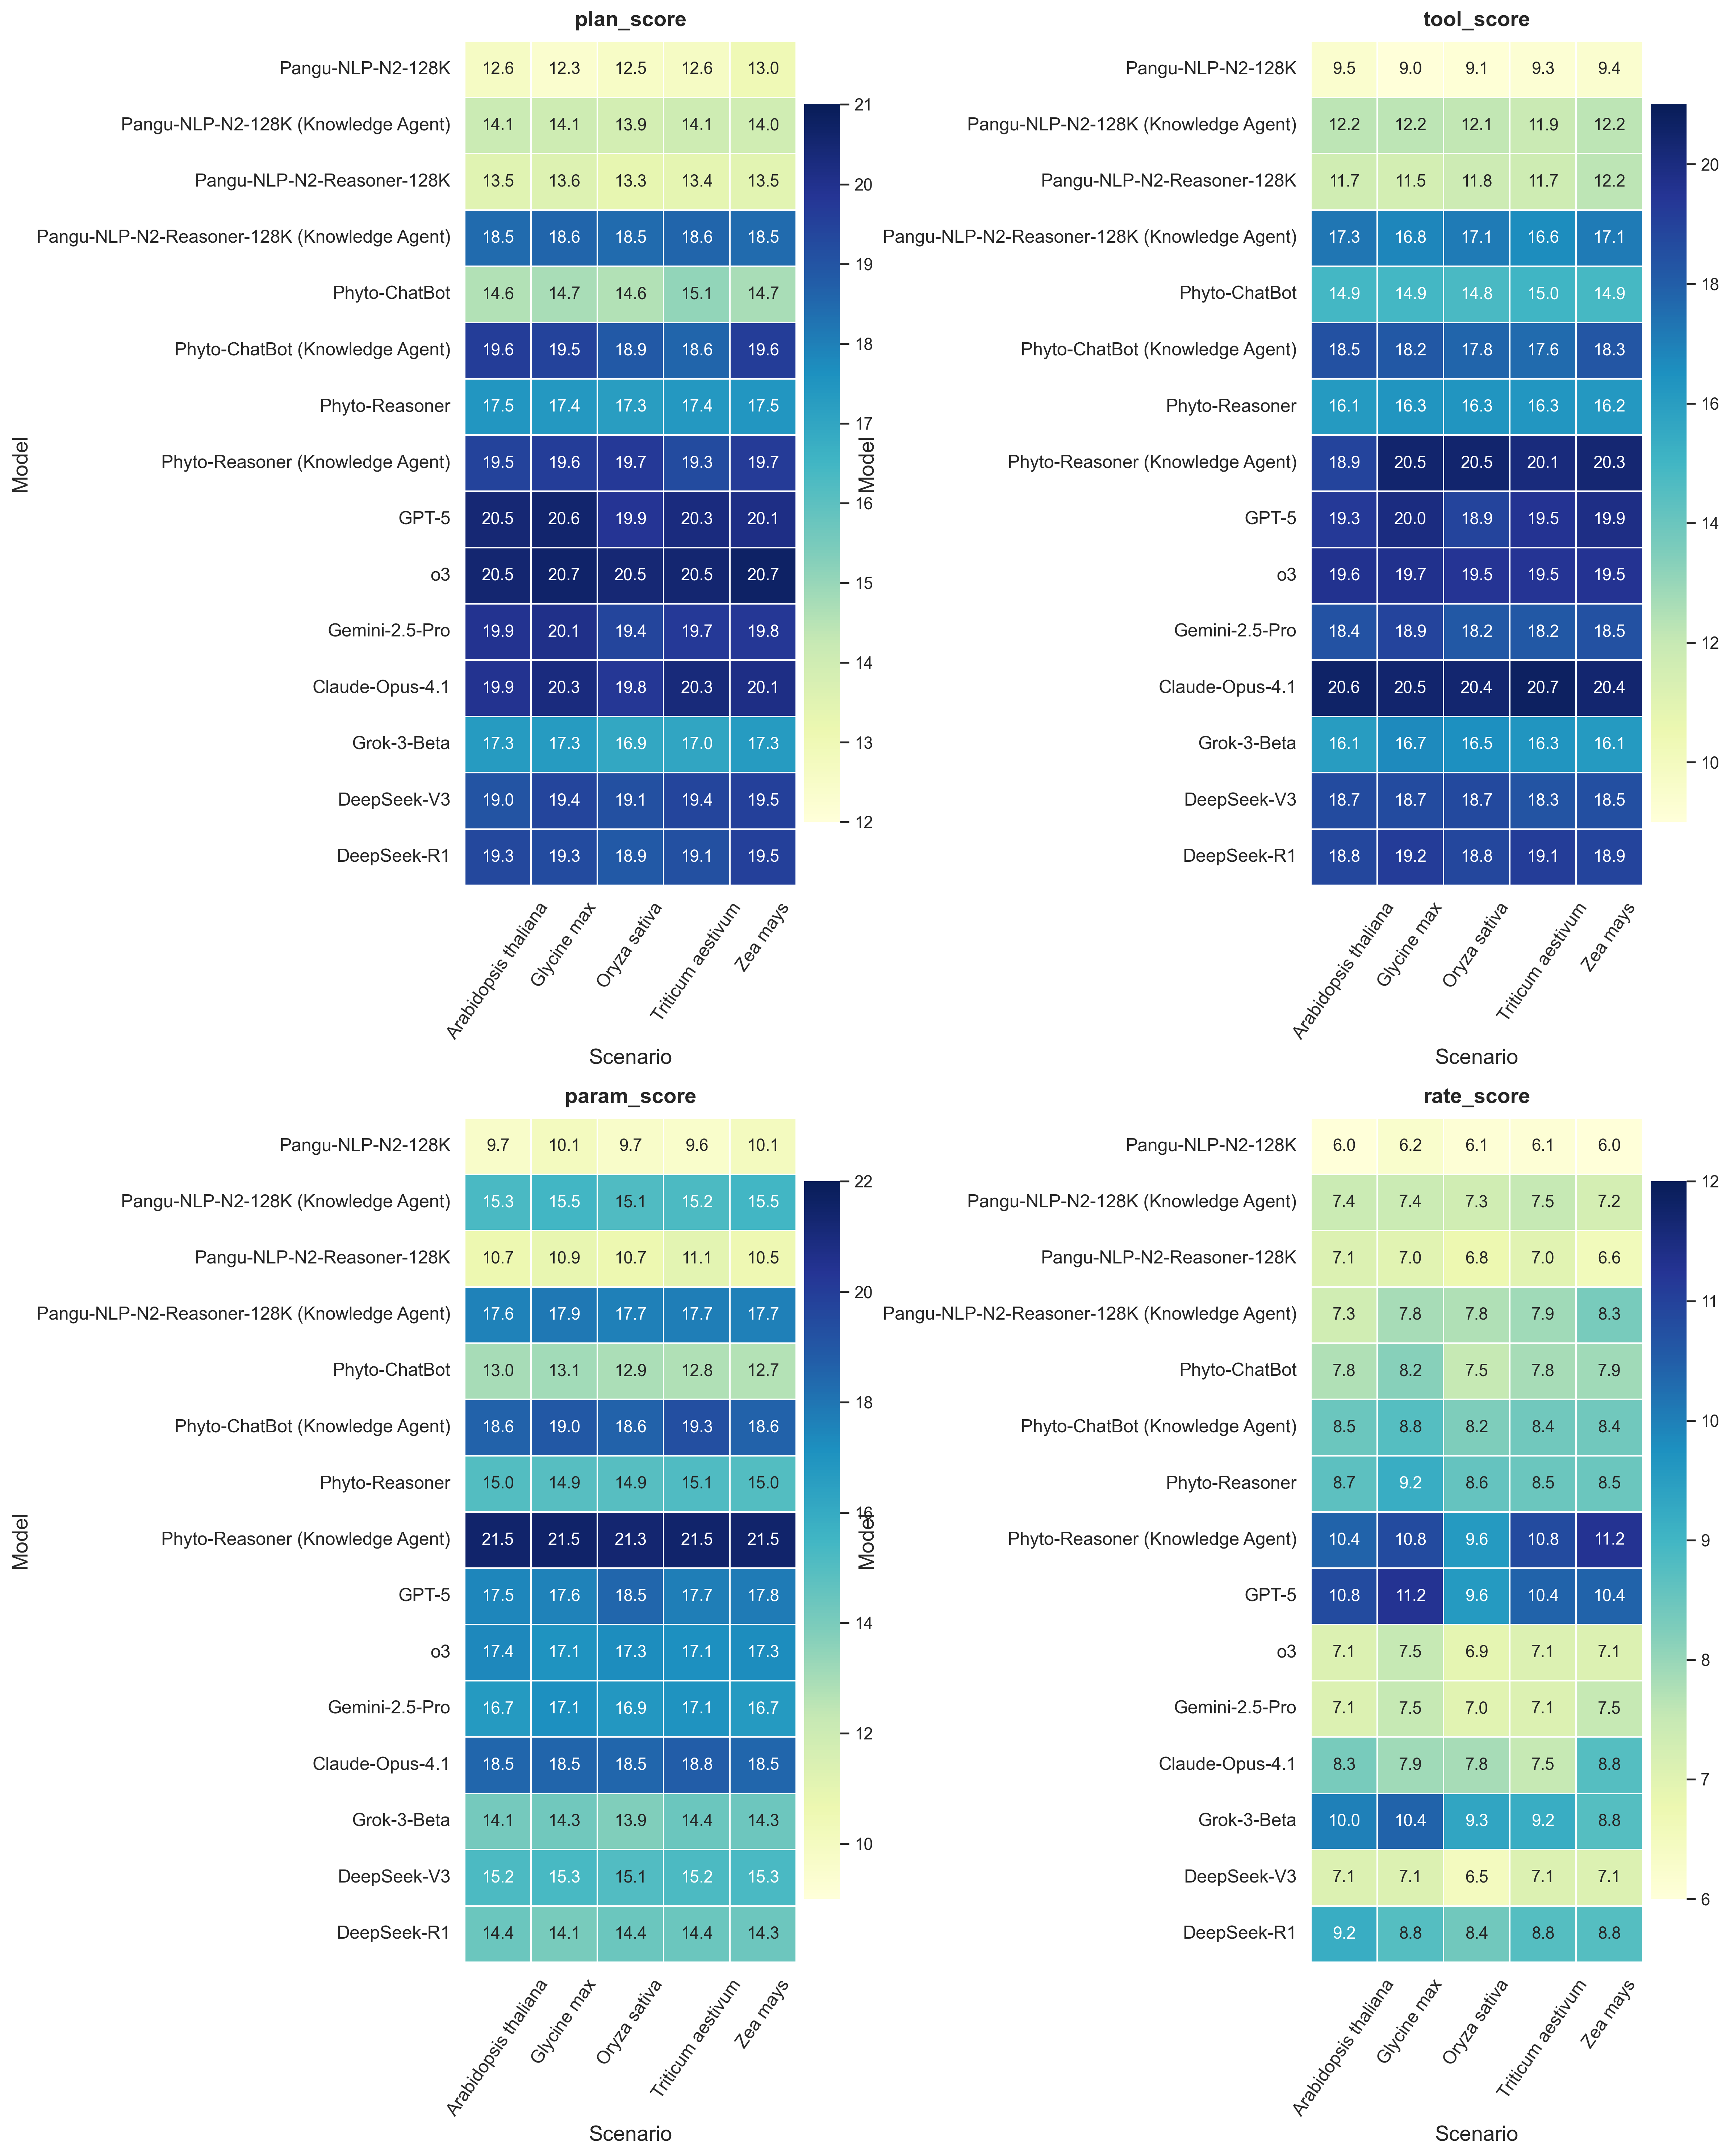

In [4]:
metrics = {
    "plan_score": plot_plan_df,
    "tool_score": plot_tool_df,
    "param_score": plot_param_df,
    "rate_score": plot_rate_df
}

scenario_order = [
    'Transcriptome', 'Proteomics', 'Metabolome', 'Evolution', 'Epicgenetic',
    'Genome-CallSNP', 'Genome-GWAS', 'Genome-GS', 'SingleCell', 'Spatial'
]
model_order = [
    'Pangu-NLP-N2-128K', 'Pangu-NLP-N2-128K (Knowledge Agent)', 'Pangu-NLP-N2-Reasoner-128K', 'Pangu-NLP-N2-Reasoner-128K (Konwledge Agent)', 
    'Phyto-ChatBot', 'Phyto-ChatBot (Konwledge Agent)', 'Phyto-Reasoner', 'Phyto-Reasoner (Knowledge Agent)', 
    'GPT-5', 'o3', 'Gemini-2.5-Pro', 'Claude-Opus-4.1', 'Grok-3-Beta', 'DeepSeek-V3', 'DeepSeek-R1'
]

def get_nice_range(values, step=1):
    vmin = np.nanmin(values)
    vmax = np.nanmax(values)
    vmin = math.floor(vmin / step) * step
    vmax = math.ceil(vmax / step) * step
    if vmin == vmax:
        vmax = vmin + step
    return vmin, vmax


fig, axes = plt.subplots(2, 2, figsize=(16, 20), dpi=300)
axes = axes.flatten()
for i, (title, pivot) in enumerate(metrics.items()):
    vmin, vmax = get_nice_range(pivot.values, step=1)
    sns.heatmap(
        pivot,
        ax=axes[i],
        cmap="YlGnBu",
        annot=True,
        fmt=".1f",
        annot_kws={"size": 11},
        linewidths=0.5,
        linecolor="white",
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        cbar_kws={"shrink": 0.85, "pad": 0.02}
    )

    axes[i].set_title(title, fontsize=14, weight="bold", pad=10)
    axes[i].set_xlabel("Scenario", fontsize=14)
    axes[i].set_ylabel("Model", fontsize=14)

    axes[i].tick_params(axis="x", labelrotation=55, labelsize=12)
    axes[i].tick_params(axis="y", labelsize=12)

    for label in axes[i].get_xticklabels():
        label.set_horizontalalignment("right")


plt.tight_layout()
# plt.savefig("model_compare_agent_split_across_speciesv1.pdf")
plt.show()